<a href="https://colab.research.google.com/github/2d-game-dev/ComputerVisionProject/blob/main/Copy_of_kursayinCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


0: 480x640 3 persons, 1 car, 1 truck, 1 bird, 159.3ms
Speed: 8.9ms preprocess, 159.3ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)
Frame 1


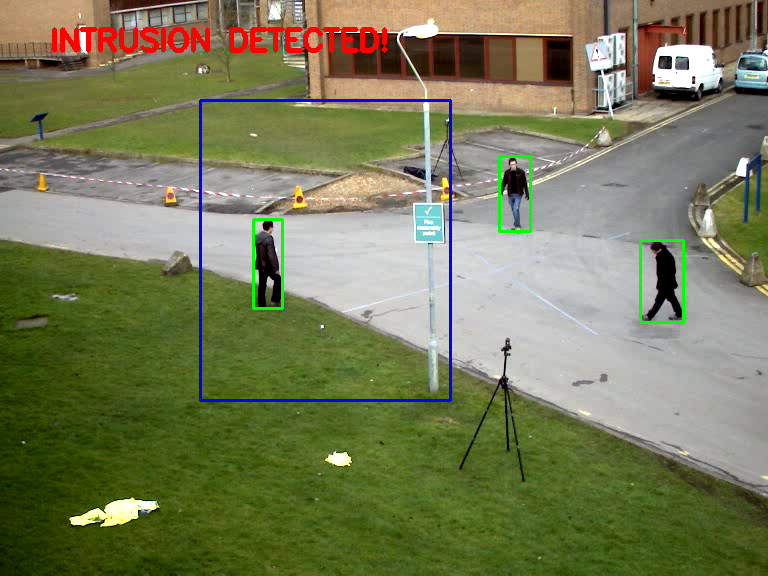


0: 480x640 3 persons, 1 car, 1 truck, 189.3ms
Speed: 7.2ms preprocess, 189.3ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)
Frame 2


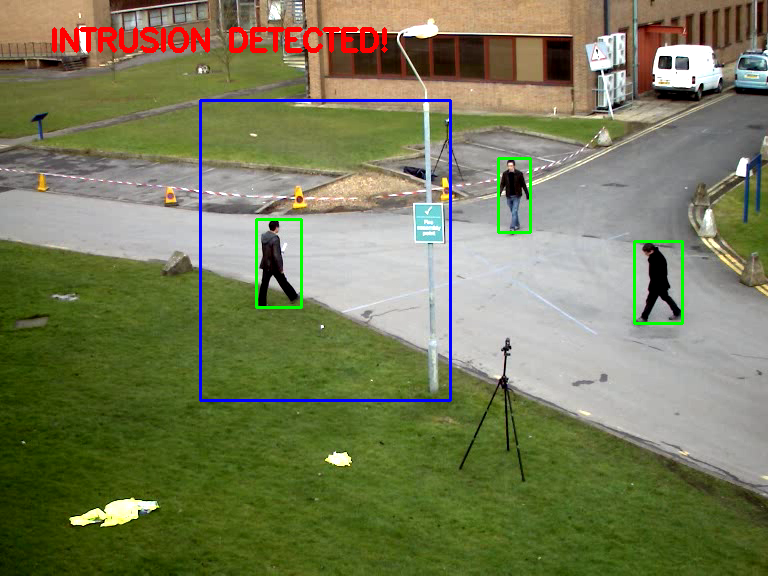

Displayed 2 frames


In [ ]:
!pip install ultralytics opencv-python matplotlib

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

model = YOLO("yolov8n.pt")  # lightweight model

# Define rectangle (x1, y1, x2, y2)
restricted_zone = (200, 100, 450, 400)

video_path = "people.mp4"
cap = cv2.VideoCapture(video_path)

# Option 1: Display only first 2 frames
max_frames = 2
frame_count = 0

while cap.isOpened() and frame_count < max_frames:
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame)

    for r in results:
        boxes = r.boxes
        for box in boxes:
            cls = int(box.cls[0])
            label = model.names[cls]

            if label == "person":
                x1, y1, x2, y2 = map(int, box.xyxy[0])

                # Draw bounding box
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 2)

                # Compute center
                cx = (x1 + x2) // 2
                cy = (y1 + y2) // 2

                # Check intrusion
                rx1, ry1, rx2, ry2 = restricted_zone

                if rx1 < cx < rx2 and ry1 < cy < ry2:
                    cv2.putText(frame, "INTRUSION DETECTED!",
                                (50,50),
                                cv2.FONT_HERSHEY_SIMPLEX,
                                1, (0,0,255), 3)

    # Draw restricted area
    cv2.rectangle(frame, (restricted_zone[0], restricted_zone[1]),
                  (restricted_zone[2], restricted_zone[3]),
                  (255,0,0), 2)

    print(f"Frame {frame_count + 1}")
    cv2_imshow(frame)
    frame_count += 1

cap.release()
print(f"Displayed {frame_count} frames")

In [ ]:
!wget -O people.mp4 https://github.com/opencv/opencv/raw/master/samples/data/vtest.avi

--2026-03-05 17:17:55--  https://github.com/opencv/opencv/raw/master/samples/data/vtest.avi
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/opencv/opencv/master/samples/data/vtest.avi [following]
--2026-03-05 17:17:56--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/vtest.avi
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8131690 (7.8M) [video/msvideo]
Saving to: ‘people.mp4’

people.mp4          100%[===================>]   7.75M  --.-KB/s    in 0.09s   

2026-03-05 17:17:56 (86.1 MB/s) - ‘people.mp4’ saved [8131690/8131690]

